In [1]:
using WaveSpec

ArgumentError: ArgumentError: Package WaveSpec not found in current path.
- Run `import Pkg; Pkg.add("WaveSpec")` to install the WaveSpec package.

In [2]:
using WaveSpec.ContinuousSpectrums
using WaveSpec.SpectralSampling
using WaveSpec.SpectralSpreading

# 1. Setup
Hs = 3.0
spec = JONSWAP(Hs, 10.0)
nf = 10

# 2. Discretize using the Energy Domain marker
# We use UniformSampling here to get 'Equal Energy' steps
ds = DiscreteSpectralSpreading(spec, UniformSampling(), get_fmin(spec), get_fmax(spec), nf; 
                        domain=SpectralSampling.Energy, mess=false)

# 3. Get amplitudes
amplitudes = get_amplitudes(ds)

energies = 0.5 * amplitudes .^2

ArgumentError: ArgumentError: Package WaveSpec not found in current path.
- Run `import Pkg; Pkg.add("WaveSpec")` to install the WaveSpec package.

In [3]:
using Plots 

fmin = get_fmin(spec)
fmax = get_fmax(spec)
f_plot = range(fmin, fmax, length=500)

p1 = plot(f_plot, [ContinuousSpectrums.get_density(spec, f) for f in f_plot], title="Continuous JONSWAP Spectrum",
    xlabel="Frequency [Hz]", ylabel="Density [m²/Hz]", linewidth=2, legend=false)


UndefVarError: UndefVarError: `get_fmin` not defined

In [4]:
# Calculate the CDF within the [fmin, fmax] range
f_fine = range(fmin, fmax, length=2000)
f_central_fine = (f_fine[1:end-1] + f_fine[2:end]) ./ 2.0
df = diff(f_fine)
S_fine = [ContinuousSpectrums.get_density(spec,f) for f in f_central_fine]

p2 = plot(f_central_fine, S_fine .* df, 
    linecolor=:red, linewidth=2,
    label="Energy Spectrum", xlabel="Frequency [Hz]", ylabel="Spectral Energy")

# plot!(f_central_fine, sqrt.(2 * S_fine .* df), 
#     linecolor=:blue, linewidth=2,
#     label="Spectral Amplitude",
#     xlabel="Frequency [Hz]", ylabel="Spectral Energy")

UndefVarError: UndefVarError: `fmin` not defined

In [5]:
cdf_vals = vcat(0.0, cumsum(S_fine .* df))
cdf_norm = cdf_vals ./ cdf_vals[end]

p3 = plot(f_fine, cdf_norm, 
    linecolor=:red, linewidth=2,
    label="Normalized CDF", title="Energy Accumulation (CDF)",
    xlabel="Frequency [Hz]", ylabel="Cumulative Energy [%]", legend=false)

UndefVarError: UndefVarError: `S_fine` not defined

In [6]:
# Uniform sampling in energy domain <=> frequency bins containing equal energy 

# 1. Define uniform target energy levels (e.g., 10 bins)
nf = 10
Ei_norm = collect(range(1.0e-5, 1.0, length=nf)) 

# 2. Map these to frequencies using your inverse CDF function
# (Using the f_fine and cdf_norm from Step 2)

function approx_inverse_cdf(cdf, f_fine, Ei, nf)
    f_target = zeros(nf)

    for (i, E_target) in enumerate(Ei)

        # Binary Search
        idx = searchsortedfirst(cdf, E_target)
        
        # # Linear Interpolation
        # p0, p1 = cdf[idx-1], cdf[idx]
        # f0, f1 = f_fine[idx-1], f_fine[idx]
    
        # f_target[i] = f0 + (E_target - p0) * (f1 - f0) / (p1 - p0)
        f_target[i] = f_fine[idx-1]
    end

    return f_target
end

mapped_freqs = approx_inverse_cdf(cdf_norm, f_fine, Ei_norm, nf)

# 3. Create the Visualization
p4 = plot(f_fine, cdf_norm, label="CDF", color=:red, lw=2, legend=:bottomright,
          title="Step 3: Energy-to-Frequency Mapping",
          xlabel="Frequency [Hz]", ylabel="Normalized Energy")

for (i, p_val) in enumerate(Ei_norm)
    f_val = mapped_freqs[i]
    
    # Draw horizontal projection
    plot!([fmin, f_val], [p_val, p_val], color=:gray, alpha=0.5, label=i==1 ? "Energy Slices" : "")
    # Draw vertical projection
    plot!([f_val, f_val], [0, p_val], color=:blue, style=:dash, alpha=0.5, label=i==1 ? "Mapped Frequencies" : "")
end

# Add markers at the mapping points
scatter!(mapped_freqs, Ei_norm, color=:black, markersize=4, label="Mapping Points")


UndefVarError: UndefVarError: `cdf_norm` not defined

In [7]:
mapped_freqs, Ei_norm

UndefVarError: UndefVarError: `mapped_freqs` not defined

In [8]:
# Calculate midpoints for sampling density
f_centers = (mapped_freqs[1:end-1] .+ mapped_freqs[2:end]) ./ 2.0
dfs = diff(mapped_freqs)
S_sampled = [ContinuousSpectrums.get_density(spec, f) for f in f_centers]

amplitudes_not_normalised = sqrt.(2 * S_sampled .* dfs)

UndefVarError: UndefVarError: `mapped_freqs` not defined

In [9]:
# 4. Compute moments with discretization error
m₀ = sum(S_sampled .* dfs)

# 5. Normalization factor (Energy Preservation)
norm_factor = (Hs / (4.0 * sqrt(m₀)))^2

# Normalise samples
densities = S_sampled * norm_factor

# The "Energy" of each discrete component
amplitudes = sqrt.(2 * densities .* dfs) 


UndefVarError: UndefVarError: `S_sampled` not defined

In [10]:
# Compute cdf with mapped frequencies to see if they match energy samples
f_central_mapped = (mapped_freqs[1:end-1] + mapped_freqs[2:end]) ./ 2.0
df = diff(mapped_freqs)
S_mapped = [ContinuousSpectrums.get_density(spec,f) for f in f_central_mapped]

cdf_mapped = vcat(0.0, cumsum(S_mapped .* df))
cdf_mapped_norm = cdf_mapped ./ cdf_mapped[end]


UndefVarError: UndefVarError: `mapped_freqs` not defined

In [11]:
Ei_norm

10-element Vector{Float64}:
 1.0e-5
 0.11112
 0.22223
 0.33334
 0.44445
 0.55556
 0.66667
 0.77778
 0.88889
 1.0

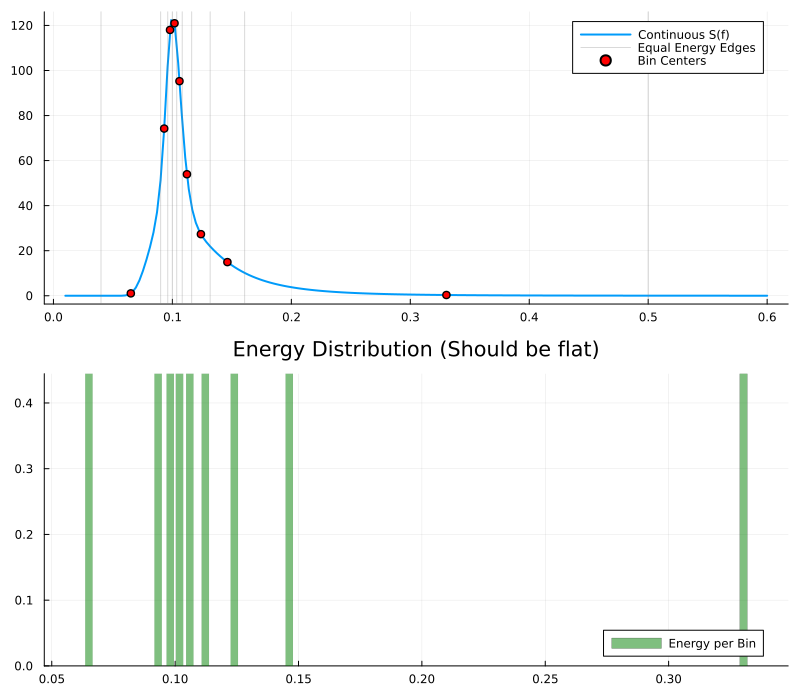

In [12]:
# TRY FROM SCRATCH TO DISCRETISE JONSWAP CONTINUOUS SPECTRUM USING UNIFORM ENERGY SAMPLING

using Plots, LinearAlgebra

# 1. Define the JONSWAP Spectrum
function jonswap(f; fp=0.1, Hs=2.0, gamma=3.3)
    f <= 0.0 && return 0.0
    # Standard formula
    alpha = (Hs^2 * fp^4) / (0.065 * gamma^0.803 + 0.135) # JONSWAP normalization
    sigma = f <= fp ? 0.07 : 0.09
    r = exp(-(f - fp)^2 / (2 * sigma^2 * fp^2))
    
    term1 = alpha * f^-5
    term2 = exp(-1.25 * (fp / f)^4)
    term3 = gamma^r
    
    return term1 * term2 * term3
end

# 2. Discretization Function
function discretize_equal_energy(fmin, fmax, n_bins)
    # Step A: Create a high-res CDF for lookup
    f_fine = range(fmin, fmax, length=2000)
    df_fine = step(f_fine)
    S_fine = [jonswap(f) for f in f_fine]
    
    # Numerical Integration (Cumulative sum of energy)
    energies_fine = S_fine .* df_fine
    cdf = vcat(0.0, cumsum(energies_fine))
    total_energy_truncated = cdf[end]
    cdf_norm = cdf ./ total_energy_truncated
    
    # Step B: Find Frequency Edges for equal energy slices
    # For N bins, we need N+1 edges (0%, 10%, 20%, ..., 100%)
    energy_targets = range(0.0, 1.0, length=n_bins + 1)
    
    f_edges = [get_f_from_p(p, cdf_norm, f_fine) for p in energy_targets]
    
    # Step C: Define Representative Frequencies (Centers) and Amplitudes
    # The key: Each bin has EXACTLY (total_energy / n_bins)
    energy_per_bin = total_energy_truncated / n_bins
    amplitudes = fill(sqrt(2.0 * energy_per_bin), n_bins)
    
    # For centers, we use the arithmetic mean of the edges
    f_centers = (f_edges[1:end-1] .+ f_edges[2:end]) ./ 2.0
    
    return f_edges, f_centers, amplitudes
end

# Helper to invert the CDF
function get_f_from_p(p, cdf_norm, f_fine)
    idx = searchsortedfirst(cdf_norm, p)
    idx == 1 && return f_fine[1]
    idx > length(f_fine) && return f_fine[end]
    # Linear interpolation for precision
    p0, p1 = cdf_norm[idx-1], cdf_norm[idx]
    f0, f1 = f_fine[idx-1], f_fine[idx]
    return f0 + (p - p0) * (f1 - f0) / (p1 - p0)
end

# 3. Execution and Plotting
fmin, fmax = 0.04, 0.5
n_bins = 9
f_edges, f_centers, amps = discretize_equal_energy(fmin, fmax, n_bins)

# Visualization
p1 = plot(range(0.01, 0.6, length=200), jonswap, label="Continuous S(f)", lw=2)
vline!(f_edges, color=:gray, alpha=0.3, label="Equal Energy Edges")
scatter!(f_centers, [jonswap(f) for f in f_centers], label="Bin Centers", color=:red)

# Histogram of Energy
bin_energies = (amps.^2) ./ 2.0
p2 = bar(f_centers, bin_energies, width=diff(f_edges), alpha=0.5, 
         label="Energy per Bin", color=:green, title="Energy Distribution (Should be flat)")

plot(p1, p2, layout=(2,1), size=(800, 700))

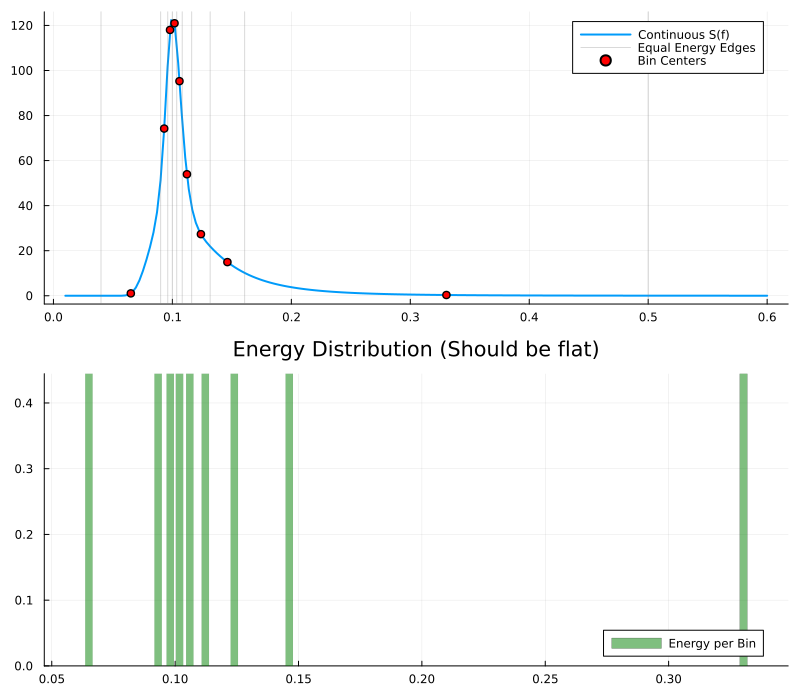

In [13]:
function discretize_energy_domain_robust(fmin, fmax, n_bins)
    # 1. High-res CDF (The "Truth")
    f_fine = range(fmin, fmax, length=2000)
    df_fine = step(f_fine)
    S_fine = [jonswap(f) for f in f_fine]
    
    # We store the RAW (not normalized) CDF to keep physical units (m^2)
    cdf_raw = vcat(0.0, cumsum(S_fine .* df_fine))
    total_energy = cdf_raw[end]
    cdf_norm = cdf_raw ./ total_energy
    
    # 2. Find Frequency Edges via Inverse CDF
    energy_targets = range(0.0, 1.0, length=n_bins + 1)
    f_edges = [get_f_from_p(p, cdf_norm, f_fine) for p in energy_targets]
    
    # 3. Compute REAL amplitudes using the frequency edges
    # We derive these by looking at the energy contained between f_low and f_high
    amplitudes = zeros(n_bins)
    for i in 1:n_bins
        f_low = f_edges[i]
        f_high = f_edges[i+1]
        
        # Method: Integrate S(f) between edges
        # In a DiscreteSpectralSpreading constructor, you'd do:
        # energy_in_bin = integrate(spec, f_low, f_high)
        
        # For this demo, we use the CDF we already built:
        energy_in_bin = get_energy_between(f_low, f_high, cdf_raw, f_fine)
        amplitudes[i] = sqrt(2.0 * energy_in_bin)
    end
    
    f_centers = (f_edges[1:end-1] .+ f_edges[2:end]) ./ 2.0
    return f_edges, f_centers, amplitudes
end

# Helper to get energy between two arbitrary frequencies using the CDF
function get_energy_between(fa, fb, cdf, f_fine)
    # Find energy at fb and fa via interpolation on the CDF
    e_b = interpolate_cdf(fb, cdf, f_fine)
    e_a = interpolate_cdf(fa, cdf, f_fine)
    return e_b - e_a
end

function interpolate_cdf(f_target, cdf, f_fine)
    # 1. Boundary Guards
    if f_target <= f_fine[1]   return cdf[1] end
    if f_target >= f_fine[end] return cdf[end] end

    # 2. Find the bin where f_target resides
    # searchsortedfirst finds the first index i where f_fine[i] >= f_target
    idx = searchsortedfirst(f_fine, f_target)

    # 3. Linear Interpolation
    f0, f1 = f_fine[idx-1], f_fine[idx]
    p0, p1 = cdf[idx-1], cdf[idx]

    # Calculate how far f_target is between f0 and f1 (0.0 to 1.0)
    t = (f_target - f0) / (f1 - f0)

    # Return the weighted energy value
    return p0 + t * (p1 - p0)
end


# 3. Execution and Plotting
fmin, fmax = 0.04, 0.5
n_bins = 9
f_edges, f_centers, amps = discretize_energy_domain_robust(fmin, fmax, n_bins)

# Visualization
p1 = plot(range(0.01, 0.6, length=200), jonswap, label="Continuous S(f)", lw=2)
vline!(f_edges, color=:gray, alpha=0.3, label="Equal Energy Edges")
scatter!(f_centers, [jonswap(f) for f in f_centers], label="Bin Centers", color=:red)

# Histogram of Energy
bin_energies = (amps.^2) ./ 2.0
p2 = bar(f_centers, bin_energies, width=diff(f_edges), alpha=0.5, 
         label="Energy per Bin", color=:green, title="Energy Distribution (Should be flat)")

plot(p1, p2, layout=(2,1), size=(800, 700))

In [14]:
# Compute energies with sampled frequencies
df = diff(f_edges)
S_mapped = [jonswap(f) for f in f_centers]

energies = S_mapped .* df


9-element Vector{Float64}:
 0.052688020875086124
 0.4438829949039167
 0.4528526864134062
 0.4468751352618218
 0.44130901262262506
 0.42720354272035815
 0.4260956506458347
 0.4327099529151332
 0.11204475661117126

The reason the results are "wrong" in the tails is a fundamental issue of geometry.
When computing energies = S .* df, we are using the Rectangle Rule (specifically, the Midpoint Rule), that is we evaluate the spectral density at the center of each bin and then mutiply by the bin width. 
This assumes the spectrum is a flat horizontal line across the entire width of the bin. In the tails of a 
JONSWAP spectrum, the curve is not flat—it is dropping off with a steep power law $f^{-5}$.

In order to see that in fact the sampled frequencies provide energetically equal bins, we need to integrate the energy more accurately, with more resolution.

In [15]:
# Lets integrate the energy in each bin
n_substeps = 100 
amplitudes = zeros(n_bins)
energies = zeros(n_bins)

for i in 1:n_bins
    # 1. Define the bin boundaries
    f_start = f_edges[i]
    f_end   = f_edges[i+1]
    
    # 2. Create a micro-grid inside this specific bin
    # We sample n_substeps points to capture the curve's shape
    f_micro = range(f_start, f_end, length=n_substeps)
    df = (f_end - f_start) / (n_substeps - 1)
    
    # 3. Integrate S(f) using the Trapezoidal Rule
    bin_energy = 0.0
    for j in 1:(n_substeps - 1)
        S0 = jonswap(f_micro[j])
        S1 = jonswap(f_micro[j+1])
        
        # Area of a small trapezoid: (average height) * width
        bin_energy += 0.5 * (S0 + S1) * df
    end
    # Save energy
    energies[i] = bin_energy
    # 4. Convert energy to amplitude: A = sqrt(2 * m0_bin)
    amplitudes[i] = sqrt(2.0 * bin_energy)
end

#amplitudes
energies   

9-element Vector{Float64}:
 0.4505283552745336
 0.45038057626616146
 0.447043948603481
 0.44315624156891154
 0.4406152967284715
 0.44006082646273137
 0.44246949943906444
 0.443162362649445
 0.44360044864643955

In [16]:
# HENCE, WE NOW RETURN TO WaveSpec

n_substeps = 100
f_edges = get_frequencies(ds)
energies = zeros(ds.nbands)

for i in 1:ds.nbands
    # 1. Define the bin boundaries
    f_start = f_edges[i]
    f_end   = f_edges[i+1]
    
    # 2. Create a micro-grid inside this specific bin
    # We sample n_substeps points to capture the curve's shape
    f_micro = range(f_start, f_end, length=n_substeps)
    df = (f_end - f_start) / (n_substeps - 1)
    
    # 3. Integrate S(f) using the Trapezoidal Rule
    bin_energy = 0.0
    for j in 1:(n_substeps - 1)
        S0 = ContinuousSpectrums.get_density(spec, f_micro[j])
        S1 = ContinuousSpectrums.get_density(spec, f_micro[j+1])
        
        # Area of a small trapezoid: (average height) * width
        bin_energy += 0.5 * (S0 + S1) * df
    end
    # Save energy
    energies[i] = bin_energy
end

energies  

UndefVarError: UndefVarError: `get_frequencies` not defined

In [17]:
expected_energy = (Hs/4.0)^2 / ds.nbands

UndefVarError: UndefVarError: `Hs` not defined

In [18]:
using Test

@test all(isapprox.(energies, expected_energy, rtol=5e-3))

Error During Test at /home/elmanyer/Documents/TU-Delft/WaveSpec.jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X24sZmlsZQ==.jl:3
  Test threw exception
  Expression: all(isapprox.(energies, expected_energy, rtol = 0.005))
  UndefVarError: `expected_energy` not defined
  Stacktrace:
   [1] macro expansion
     @ ~/Documents/TU-Delft/WaveSpec.jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X24sZmlsZQ==.jl:3 [inlined]
   [2] macro expansion
     @ ~/julia-1.10.10/share/julia/stdlib/v1.10/Test/src/Test.jl:669 [inlined]
   [3] top-level scope
     @ ~/Documents/TU-Delft/WaveSpec.jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X24sZmlsZQ==.jl:3


Test.FallbackTestSetException: Test.FallbackTestSetException("There was an error during testing")

In [19]:
f_edges = get_frequencies(ds)
energies = zeros(ds.nbands)

for i in 1:ds.nbands
    # 1. Define the bin boundaries
    f_start = f_edges[i]
    f_end   = f_edges[i+1]
    # 2. Integrate using WaveSpec's integrate function
    energies[i] = integrate(spec, f_start, f_end)   
end

energies  

UndefVarError: UndefVarError: `get_frequencies` not defined